# Agent Density Metrics Analysis

Scene-centric trajectory metrics analyzing agent count and spatial density from nuScenes mini dataset.

## Setup and Data Loading

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm.auto import tqdm
from collections import defaultdict
import warnings
import yaml
warnings.filterwarnings('ignore')

# Import trajdata
from trajdata import UnifiedDataset

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries loaded successfully")

/Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ Libraries loaded successfully


In [2]:
# Load configuration
CONFIG_PATH = Path('../config/analysis_config.yaml')
with open(CONFIG_PATH, 'r') as f:
    config = yaml.safe_load(f)

print(f"✓ Configuration loaded from {CONFIG_PATH}")

✓ Configuration loaded from ../config/analysis_config.yaml


In [3]:
# Configure paths from config
NUSCENES_ROOT = Path(config['dataset']['root_path']).resolve()
CACHE_DIR = Path(config['dataset']['cache_path']) / config['dataset']['name']
CACHE_DIR = CACHE_DIR.resolve()
RESULTS_DIR = Path(config['output']['results_dir']).resolve()
PLOTS_DIR = Path(config['output']['plots_dir']).resolve()
METRICS_DIR = Path(config['output']['metrics_dir']).resolve()

# Create output directories
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
METRICS_DIR.mkdir(parents=True, exist_ok=True)

if not NUSCENES_ROOT.exists():
    raise FileNotFoundError(f"nuScenes root not found at {NUSCENES_ROOT}")

print(f"Data directory: {NUSCENES_ROOT}")
print(f"Cache directory: {CACHE_DIR}")
print(f"Plots directory: {PLOTS_DIR}")
print(f"Metrics directory: {METRICS_DIR}")

Data directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/data/raw
Cache directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/data/processed/trajdata_cache/nusc_mini
Plots directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/plots/characterization
Metrics directory: /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/metrics


In [4]:
# Extract scene-centric configuration
scene_config = config['trajdata']['scene_centric']

# Load dataset in scene-centric mode
dataset = UnifiedDataset(
    desired_data=[config['dataset']['name']],
    centric="scene",
    desired_dt=scene_config['desired_dt'],
    history_sec=tuple(scene_config['history_sec']),
    future_sec=tuple(scene_config['future_sec']),
    incl_raster_map=False,
    incl_vector_map=False,
    verbose=True,
    data_dirs={config['dataset']['name']: str(NUSCENES_ROOT)},
    cache_location=str(CACHE_DIR.parent) if CACHE_DIR.exists() else None,
    num_workers=config['trajdata']['num_workers'],
)

print(f"\n✓ Dataset loaded: {len(dataset)} scene batches")

Loading data for matched scene tags: ['mini_train-boston-nusc_mini', 'mini_train-singapore-nusc_mini', 'mini_val-boston-nusc_mini', 'mini_val-singapore-nusc_mini']


Calculating Agent Data (Serially): 100%|██████████| 10/10 [00:00<00:00, 44858.87it/s]


10 scenes in the scene index.


Structuring Scene Data Index: 100%|██████████| 10/10 [00:00<00:00, 530924.56it/s]


✓ Dataset loaded: 404 scene batches


## Metric 1: Instantaneous Agent Count

Extract number of agents per timestamp, grouped by scene.

### Implementation Details

**What:** Counts the number of agents present at each timestep across all scene batches.

**How:**
1. Iterate through all scene batches in the dataset (404 total)
2. For each batch, extract:
   - Scene identifier (`scene_ids`)
   - Number of agents present (`num_agents`)
   - Batch index for reference
3. Store results in a DataFrame with columns: `scene_name`, `batch_idx`, `num_agents`
4. Calculate descriptive statistics (mean, median, std, min, max)

**Purpose:** Understand temporal variation in scene complexity and agent interactions.

In [5]:
# Collect instantaneous agent counts with agent type breakdown
print("Collecting instantaneous agent counts...")

from trajdata import AgentType

agent_counts_data = []

for idx in tqdm(range(len(dataset)), desc="Processing scene batches"):
    batch = dataset[idx]
    
    # Extract scene information - use scene_id (singular) attribute
    scene_name = batch.scene_id if hasattr(batch, 'scene_id') else f"scene_{idx}"
    num_agents = batch.num_agents.item() if hasattr(batch.num_agents, 'item') else batch.num_agents
    
    # Count agents by type - extract from agent_types_np attribute
    agent_type_counts = {}
    
    # In scene-centric mode, agent_types_np contains integer agent type values
    if hasattr(batch, 'agent_types_np') and batch.agent_types_np is not None:
        for agent_type_int in batch.agent_types_np:
            # Map integer to AgentType enum name
            try:
                type_name = AgentType(agent_type_int).name
                agent_type_counts[type_name] = agent_type_counts.get(type_name, 0) + 1
            except (ValueError, AttributeError):
                # Handle unknown agent types
                pass
    
    # Store overall count
    record = {
        'scene_name': scene_name,
        'batch_idx': idx,
        'scene_ts': batch.scene_ts if hasattr(batch, 'scene_ts') else idx,
        'num_agents': num_agents,
    }
    
    # Add agent type counts
    for agent_type, count in agent_type_counts.items():
        record[f'num_{agent_type}'] = count
    
    agent_counts_data.append(record)

agent_counts_df = pd.DataFrame(agent_counts_data).fillna(0)
print(f"✓ Collected {len(agent_counts_df)} timestep records")
print(f"Unique scenes: {agent_counts_df['scene_name'].nunique()}")
print(f"\nOverall agent count statistics:")
print(agent_counts_df['num_agents'].describe())

# Check if agent type data was collected
agent_type_cols = [col for col in agent_counts_df.columns if col.startswith('num_') and col != 'num_agents']
if agent_type_cols:
    print(f"\n✓ Agent type data collected: {[col.replace('num_', '') for col in agent_type_cols]}")
    print(f"\nAgent type distribution (mean counts per timestep):")
    for col in sorted(agent_type_cols):
        agent_type = col.replace('num_', '')
        mean_count = agent_counts_df[col].mean()
        max_count = agent_counts_df[col].max()
        print(f"  • {agent_type}: {mean_count:.2f} (mean), {max_count:.0f} (max)")
else:
    print("\n⚠ No agent type data available - visualizations will show overall counts only")

Processing scene batches: 100%|██████████| 404/404 [00:03<00:00, 117.38it/s]

✓ Collected 404 timestep records
Unique scenes: 10

Overall agent count statistics:
count    404.000000
mean      37.316832
std       18.749852
min        9.000000
25%       21.000000
50%       35.000000
75%       56.000000
max       74.000000
Name: num_agents, dtype: float64

✓ Agent type data collected: ['VEHICLE', 'BICYCLE', 'PEDESTRIAN', 'MOTORCYCLE']

Agent type distribution (mean counts per timestep):
  • BICYCLE: 0.60 (mean), 4 (max)
  • MOTORCYCLE: 1.16 (mean), 8 (max)
  • PEDESTRIAN: 12.47 (mean), 44 (max)
  • VEHICLE: 23.08 (mean), 61 (max)


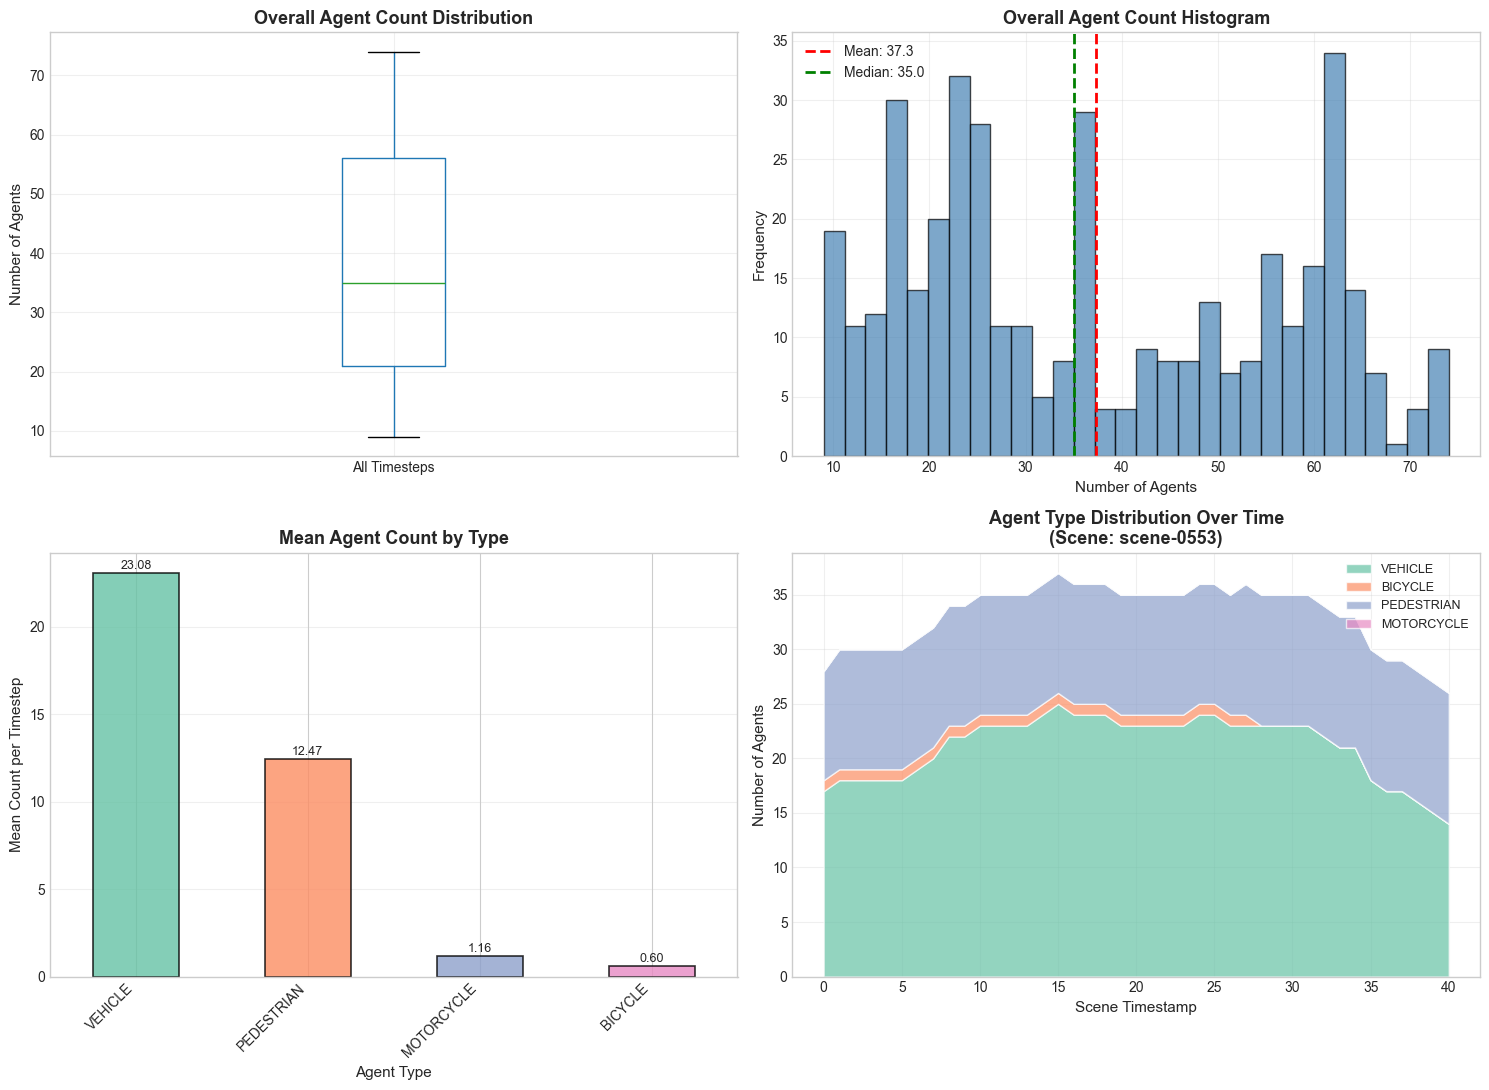


AGENT COUNT STATISTICS BY TYPE

BICYCLE:
  Mean:     0.60
  Median:   0.00
  Std Dev:  0.95
  Min/Max:  0 / 4
  Total:    242 agent-timesteps

MOTORCYCLE:
  Mean:     1.16
  Median:   0.00
  Std Dev:  1.94
  Min/Max:  0 / 8
  Total:    470 agent-timesteps

PEDESTRIAN:
  Mean:     12.47
  Median:   9.00
  Std Dev:  13.10
  Min/Max:  0 / 44
  Total:    5038 agent-timesteps

VEHICLE:
  Mean:     23.08
  Median:   18.00
  Std Dev:  13.86
  Min/Max:  5 / 61
  Total:    9326 agent-timesteps

✓ Plot saved to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/plots/characterization/instantaneous_agent_count.png


In [6]:
# Visualize instantaneous agent counts
agent_type_cols = [col for col in agent_counts_df.columns if col.startswith('num_') and col != 'num_agents']

# Decide layout based on whether agent type data exists
if len(agent_type_cols) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    has_agent_types = True
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    has_agent_types = False

# Make axes indexable consistently
if not has_agent_types:
    axes_flat = axes
    axes = np.empty((2, 2), dtype=object)
    axes[0, 0] = axes_flat[0]
    axes[0, 1] = axes_flat[1]

# Box plot - overall
ax = axes[0, 0]
agent_counts_df.boxplot(column='num_agents', ax=ax)
ax.set_title('Overall Agent Count Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Agents', fontsize=11)
ax.set_xticklabels(['All Timesteps'])
ax.grid(True, alpha=0.3)

# Histogram - overall
ax = axes[0, 1]
ax.hist(agent_counts_df['num_agents'], bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('Overall Agent Count Histogram', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Agents', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.axvline(agent_counts_df['num_agents'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {agent_counts_df['num_agents'].mean():.1f}")
ax.axvline(agent_counts_df['num_agents'].median(), color='green', linestyle='--', linewidth=2,
           label=f"Median: {agent_counts_df['num_agents'].median():.1f}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Additional plots only if agent type data exists
if has_agent_types:
    # Bar chart by agent type (mean and max counts)
    ax = axes[1, 0]
    means_by_type = agent_counts_df[agent_type_cols].mean().sort_values(ascending=False)
    colors = plt.cm.Set2(range(len(means_by_type)))
    bars = means_by_type.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.set_title('Mean Agent Count by Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Agent Type', fontsize=11)
    ax.set_ylabel('Mean Count per Timestep', fontsize=11)
    ax.set_xticklabels([col.replace('num_', '') for col in means_by_type.index], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, val) in enumerate(means_by_type.items()):
        ax.text(i, val + 0.05, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

    # Stacked area chart of agent type distribution over time (first scene)
    ax = axes[1, 1]
    first_scene = agent_counts_df['scene_name'].iloc[0]
    scene_data = agent_counts_df[agent_counts_df['scene_name'] == first_scene].sort_values('scene_ts')
    
    if len(scene_data) > 1 and len(agent_type_cols) > 0:
        # Create stacked area plot
        agent_type_data = scene_data[agent_type_cols].fillna(0)
        colors = plt.cm.Set2(range(len(agent_type_cols)))
        ax.stackplot(scene_data['scene_ts'], 
                    *[agent_type_data[col].values for col in agent_type_cols],
                    labels=[col.replace('num_', '') for col in agent_type_cols],
                    colors=colors, alpha=0.7)
        ax.set_title(f'Agent Type Distribution Over Time\n(Scene: {first_scene})', fontsize=13, fontweight='bold')
        ax.set_xlabel('Scene Timestamp', fontsize=11)
        ax.set_ylabel('Number of Agents', fontsize=11)
        ax.legend(loc='upper right', fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'instantaneous_agent_count.png', dpi=300, bbox_inches='tight')
plt.show()

# Print detailed statistics by agent type
if has_agent_types:
    print("\n" + "="*60)
    print("AGENT COUNT STATISTICS BY TYPE")
    print("="*60)
    for col in sorted(agent_type_cols):
        agent_type = col.replace('num_', '')
        data = agent_counts_df[col]
        print(f"\n{agent_type}:")
        print(f"  Mean:     {data.mean():.2f}")
        print(f"  Median:   {data.median():.2f}")
        print(f"  Std Dev:  {data.std():.2f}")
        print(f"  Min/Max:  {data.min():.0f} / {data.max():.0f}")
        print(f"  Total:    {data.sum():.0f} agent-timesteps")
    print("="*60)
else:
    print("\n⚠️ Note: Agent type differentiation not available")
    print("   Only overall agent counts are shown in the plots above")

print(f"\n✓ Plot saved to {PLOTS_DIR / 'instantaneous_agent_count.png'}")

## Metric 2: Maximum Simultaneous Agents per Scene

Compute maximum number of agents observed in each scene.

### Implementation Details

**What:** Identifies the peak number of agents simultaneously present in each scene.

**How:**
1. Group the instantaneous agent counts by `scene_name`
2. Apply `.max()` aggregation to find the maximum `num_agents` per scene
3. Reset index to create a clean DataFrame with columns: `scene_name`, `max_agents`
4. Compute summary statistics across all scenes

**Purpose:** Identify scenes with high agent density for complexity analysis and potential clustering.

In [7]:
# Calculate maximum agents per scene (overall and by type)
print("Calculating maximum simultaneous agents per scene...")

# Overall maximum
max_agents_per_scene = agent_counts_df.groupby('scene_name')['num_agents'].max().reset_index()
max_agents_per_scene.columns = ['scene_name', 'max_agents']

# Maximum by agent type
agent_type_cols = [col for col in agent_counts_df.columns if col.startswith('num_') and col != 'num_agents']
if agent_type_cols:
    max_by_type = agent_counts_df.groupby('scene_name')[agent_type_cols].max().reset_index()
    max_agents_per_scene = max_agents_per_scene.merge(max_by_type, on='scene_name')

print(f"\nMaximum agents per scene:")
print(max_agents_per_scene['max_agents'].describe())
print(f"\nScenes analyzed: {len(max_agents_per_scene)}")

if agent_type_cols:
    print("\nMaximum agents by type (across all scenes):")
    for col in agent_type_cols:
        agent_type = col.replace('num_', '')
        print(f"  {agent_type}: {max_agents_per_scene[col].max():.0f}")

Calculating maximum simultaneous agents per scene...

Maximum agents per scene:
count    10.00000
mean     46.90000
std      21.90104
min      17.00000
25%      27.50000
50%      50.50000
75%      65.75000
max      74.00000
Name: max_agents, dtype: float64

Scenes analyzed: 10

Maximum agents by type (across all scenes):
  VEHICLE: 61
  BICYCLE: 4
  PEDESTRIAN: 44
  MOTORCYCLE: 8


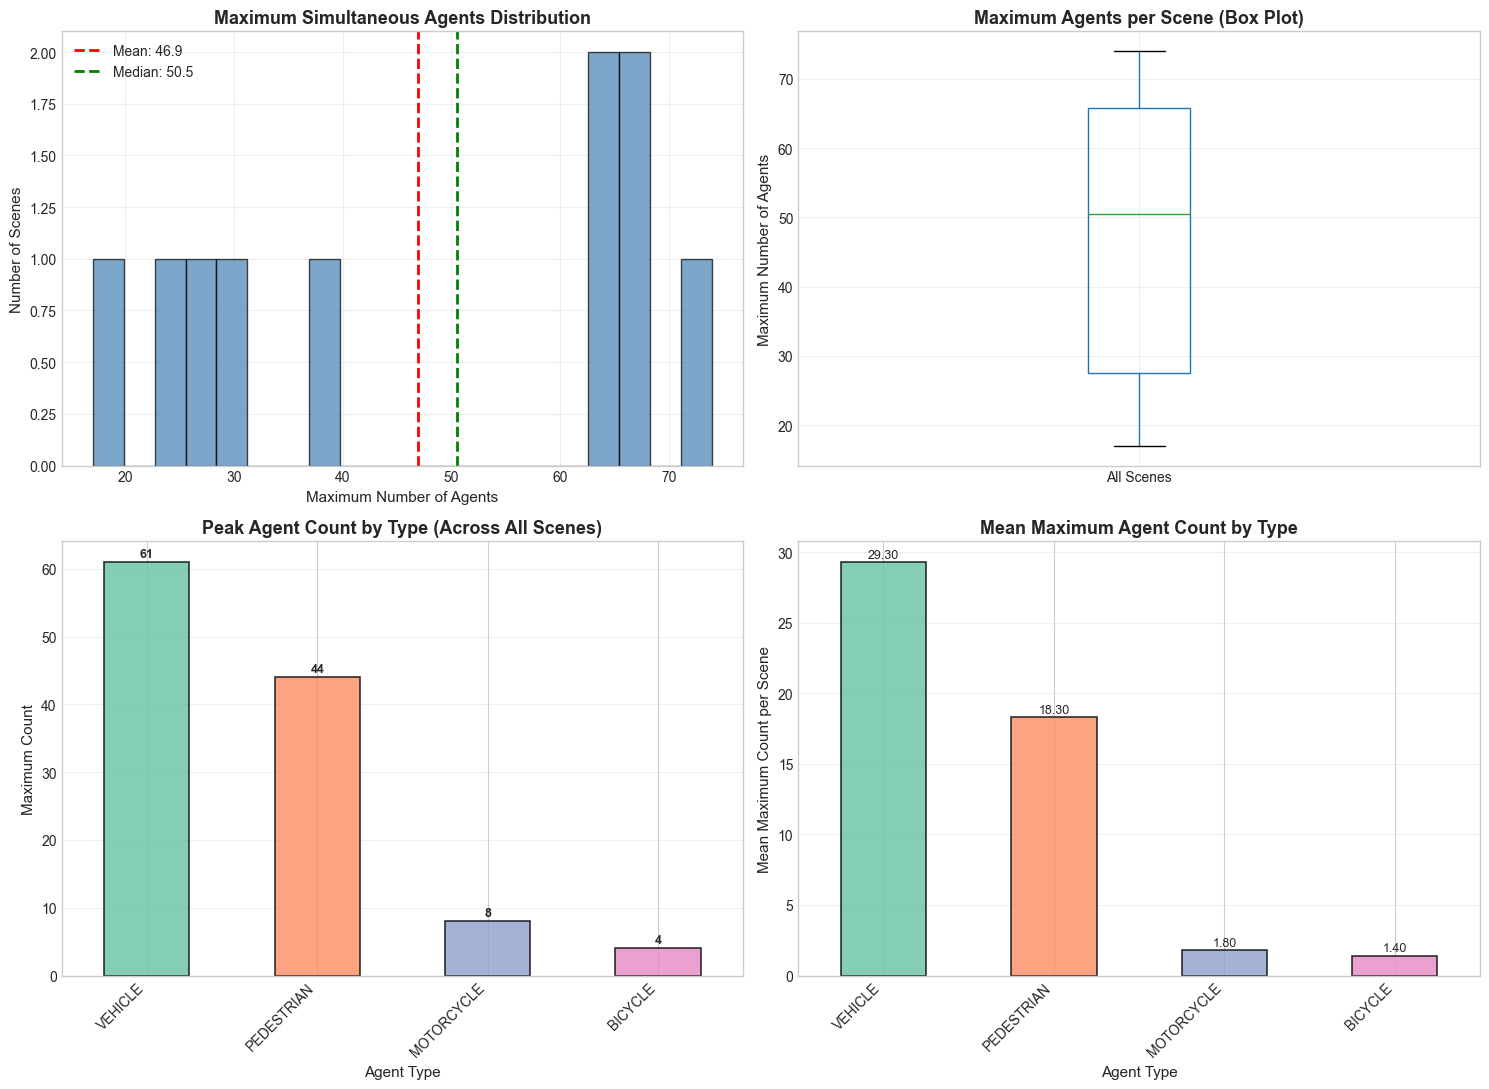


MAXIMUM AGENTS STATISTICS BY TYPE

BICYCLE:
  Peak count (all scenes): 4
  Mean max per scene:      1.40
  Median max per scene:    1.00

MOTORCYCLE:
  Peak count (all scenes): 8
  Mean max per scene:      1.80
  Median max per scene:    1.00

PEDESTRIAN:
  Peak count (all scenes): 44
  Mean max per scene:      18.30
  Median max per scene:    11.50

VEHICLE:
  Peak count (all scenes): 61
  Mean max per scene:      29.30
  Median max per scene:    23.00

✓ Plot saved to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/plots/characterization/max_simultaneous_agents.png


In [8]:
# Visualize maximum agents per scene
agent_type_cols = [col for col in max_agents_per_scene.columns if col.startswith('num_') and col != 'max_agents']

if agent_type_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    has_agent_types = True
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes = np.array([[axes[0], axes[1]], [None, None]])
    has_agent_types = False

# Overall histogram
ax = axes[0, 0]
ax.hist(max_agents_per_scene['max_agents'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.set_title('Maximum Simultaneous Agents Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Maximum Number of Agents', fontsize=11)
ax.set_ylabel('Number of Scenes', fontsize=11)
ax.axvline(max_agents_per_scene['max_agents'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {max_agents_per_scene['max_agents'].mean():.1f}")
ax.axvline(max_agents_per_scene['max_agents'].median(), color='green', linestyle='--', linewidth=2,
           label=f"Median: {max_agents_per_scene['max_agents'].median():.1f}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Box plot for overall max agents
ax = axes[0, 1]
max_agents_per_scene.boxplot(column='max_agents', ax=ax)
ax.set_title('Maximum Agents per Scene (Box Plot)', fontsize=13, fontweight='bold')
ax.set_ylabel('Maximum Number of Agents', fontsize=11)
ax.set_xticklabels(['All Scenes'])
ax.grid(True, alpha=0.3)

# Additional plots only if agent type data exists
if has_agent_types:
    # Bar chart by agent type (max across all scenes)
    ax = axes[1, 0]
    max_by_type_overall = max_agents_per_scene[agent_type_cols].max().sort_values(ascending=False)
    colors = plt.cm.Set2(range(len(max_by_type_overall)))
    max_by_type_overall.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.set_title('Peak Agent Count by Type (Across All Scenes)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Agent Type', fontsize=11)
    ax.set_ylabel('Maximum Count', fontsize=11)
    ax.set_xticklabels([col.replace('num_', '') for col in max_by_type_overall.index], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, val) in enumerate(max_by_type_overall.items()):
        ax.text(i, val + 0.3, f'{val:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    # Mean max agents by type
    ax = axes[1, 1]
    mean_max_by_type = max_agents_per_scene[agent_type_cols].mean().sort_values(ascending=False)
    colors = plt.cm.Set2(range(len(mean_max_by_type)))
    mean_max_by_type.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.set_title('Mean Maximum Agent Count by Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Agent Type', fontsize=11)
    ax.set_ylabel('Mean Maximum Count per Scene', fontsize=11)
    ax.set_xticklabels([col.replace('num_', '') for col in mean_max_by_type.index], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, val) in enumerate(mean_max_by_type.items()):
        ax.text(i, val + 0.1, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'max_simultaneous_agents.png', dpi=300, bbox_inches='tight')
plt.show()

if has_agent_types:
    print("\n" + "="*60)
    print("MAXIMUM AGENTS STATISTICS BY TYPE")
    print("="*60)
    for col in sorted(agent_type_cols):
        agent_type = col.replace('num_', '')
        data = max_agents_per_scene[col]
        print(f"\n{agent_type}:")
        print(f"  Peak count (all scenes): {data.max():.0f}")
        print(f"  Mean max per scene:      {data.mean():.2f}")
        print(f"  Median max per scene:    {data.median():.2f}")
    print("="*60)
else:
    print("\n⚠ Note: Agent type differentiation not available - showing overall counts only")

print(f"\n✓ Plot saved to {PLOTS_DIR / 'max_simultaneous_agents.png'}")

## Metric 3: Spatial Agent Density

Calculate agent density as agents per square meter using bounding box area.

### Implementation Details

**What:** Calculates agents per square meter by analyzing spatial extent and agent count.

**How:**
1. For each scene batch, extract agent positions (`agent_hist[:, -1, :2]`)
2. Compute bounding box extent:
   - Find min/max x,y coordinates across all agents
   - Calculate width = (x_max - x_min)
   - Calculate height = (y_max - y_min)
   - Compute area = width x height (in square meters)
3. Calculate spatial density = num_agents divided by bbox_area
4. Store: `scene_name`, `batch_idx`, `num_agents`, `bbox_area`, `spatial_density`

**Purpose:** Quantify spatial crowding independent of scene size for understanding interaction dynamics.

In [9]:
# Calculate spatial density with agent type breakdown
print("Calculating spatial agent density...")

from trajdata import AgentType

density_data = []

for idx in tqdm(range(len(dataset)), desc="Computing spatial density"):
    batch = dataset[idx]
    
    # Get agent positions from agent_histories (last timestep)
    if hasattr(batch, 'agent_histories') and batch.agent_histories is not None and len(batch.agent_histories) > 0:
        # Extract last timestep positions for all agents
        positions = []
        agent_types_in_batch = []
        
        # Extract agent types from agent_types_np
        batch_agent_types = []
        if hasattr(batch, 'agent_types_np') and batch.agent_types_np is not None:
            batch_agent_types = batch.agent_types_np
        
        for i, agent_hist in enumerate(batch.agent_histories):
            if len(agent_hist) > 0:  # Agent has history
                # Get last position (x, y coordinates)
                positions.append([agent_hist[-1, 0], agent_hist[-1, 1]])
                # Track agent type
                if i < len(batch_agent_types):
                    try:
                        type_name = AgentType(batch_agent_types[i]).name
                        agent_types_in_batch.append(type_name)
                    except (ValueError, AttributeError):
                        pass
        
        if len(positions) > 1:  # Need at least 2 agents for meaningful bbox
            positions = np.array(positions)
            
            # Calculate bounding box
            x_min, x_max = positions[:, 0].min(), positions[:, 0].max()
            y_min, y_max = positions[:, 1].min(), positions[:, 1].max()
            
            bbox_width = float(x_max - x_min)
            bbox_height = float(y_max - y_min)
            bbox_area = bbox_width * bbox_height
            
            # Avoid division by zero (add small epsilon for very small areas)
            if bbox_area > 0.01:  # Minimum 0.01 m² to avoid numerical issues
                num_agents = batch.num_agents.item() if hasattr(batch.num_agents, 'item') else batch.num_agents
                spatial_density = num_agents / bbox_area
                
                # Extract scene information - use scene_id (singular) attribute
                scene_name = batch.scene_id if hasattr(batch, 'scene_id') else f"scene_{idx}"
                
                # Count agents by type
                agent_type_counts = {}
                for type_name in agent_types_in_batch:
                    agent_type_counts[type_name] = agent_type_counts.get(type_name, 0) + 1
                
                # Calculate density by type and prepare output
                agent_type_densities = {}
                agent_type_count_cols = {}
                for type_name, count in agent_type_counts.items():
                    agent_type_densities[f'density_{type_name}'] = count / bbox_area
                    agent_type_count_cols[f'num_{type_name}'] = count
                
                density_data.append({
                    'scene_name': scene_name,
                    'batch_idx': idx,
                    'num_agents': num_agents,
                    'bbox_area': bbox_area,
                    'bbox_width': bbox_width,
                    'bbox_height': bbox_height,
                    'spatial_density': spatial_density,
                    **agent_type_count_cols,
                    **agent_type_densities
                })

density_df = pd.DataFrame(density_data).fillna(0)
print(f"✓ Computed density for {len(density_df)} timesteps")
if len(density_df) > 0:
    print(f"\nOverall spatial density statistics (agents/m²):")
    print(density_df['spatial_density'].describe())
    print(f"\nBounding box area statistics (m²):")
    print(density_df['bbox_area'].describe())
    
    # Print density by agent type
    density_cols = [col for col in density_df.columns if col.startswith('density_') and col != 'spatial_density']
    if density_cols:
        print(f"\n✓ Agent type density data collected: {[col.replace('density_', '') for col in sorted(density_cols)]}")
        print("\nAgent type density statistics (agents/m²):")
        for col in sorted(density_cols):
            agent_type = col.replace('density_', '')
            data = density_df[col]
            print(f"  {agent_type}:")
            print(f"    Mean:   {data.mean():.4f}")
            print(f"    Median: {data.median():.4f}")
            print(f"    Max:    {data.max():.4f}")
    else:
        print("\n⚠ No agent type density data available")
else:
    print("\n⚠ No density data was collected - check data availability")

Calculating spatial agent density...


Computing spatial density: 100%|██████████| 404/404 [00:03<00:00, 108.94it/s]

✓ Computed density for 404 timesteps

Overall spatial density statistics (agents/m²):
count    404.000000
mean       0.005747
std        0.004000
min        0.001172
25%        0.002963
50%        0.004260
75%        0.007292
max        0.018520
Name: spatial_density, dtype: float64

Bounding box area statistics (m²):
count      404.000000
mean      8159.081701
std       4920.008746
min       2026.874812
25%       4892.483915
50%       6812.881931
75%       9320.652428
max      24352.916326
Name: bbox_area, dtype: float64

✓ Agent type density data collected: ['BICYCLE', 'MOTORCYCLE', 'PEDESTRIAN', 'VEHICLE']

Agent type density statistics (agents/m²):
  BICYCLE:
    Mean:   0.0001
    Median: 0.0000
    Max:    0.0009
  MOTORCYCLE:
    Mean:   0.0002
    Median: 0.0000
    Max:    0.0018
  PEDESTRIAN:
    Mean:   0.0018
    Median: 0.0007
    Max:    0.0129
  VEHICLE:
    Mean:   0.0036
    Median: 0.0030
    Max:    0.0157


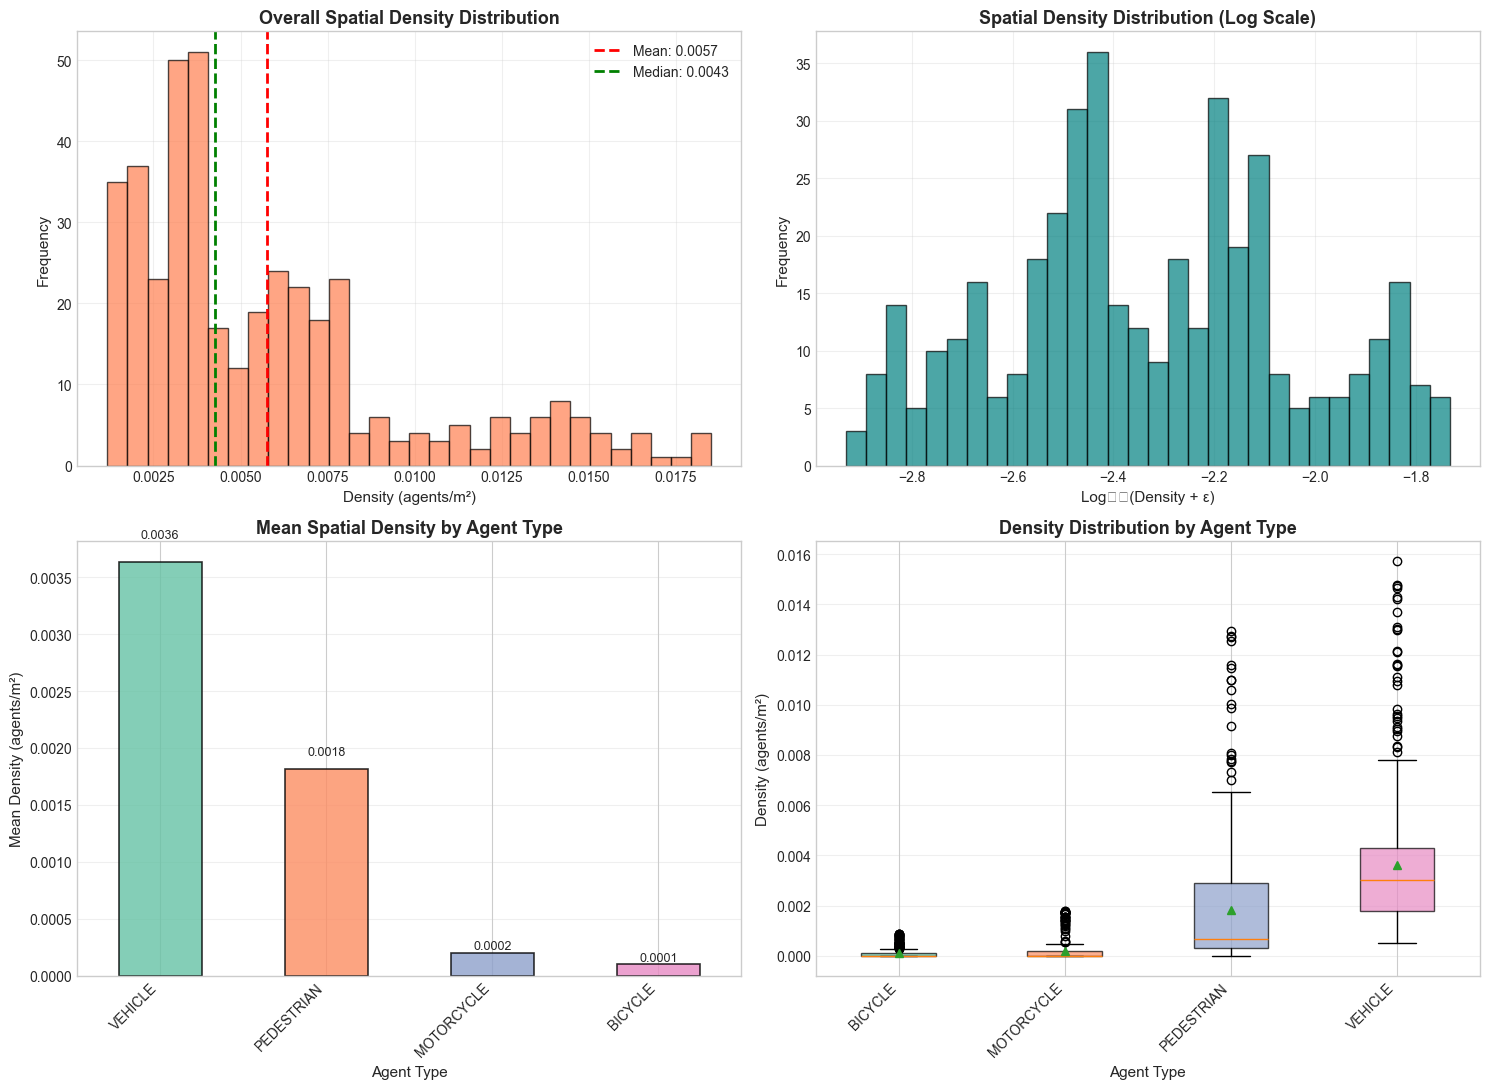


SPATIAL DENSITY STATISTICS BY TYPE

BICYCLE:
  Mean:     0.0001 agents/m²
  Median:   0.0000 agents/m²
  Std Dev:  0.0002 agents/m²
  Max:      0.0009 agents/m²

MOTORCYCLE:
  Mean:     0.0002 agents/m²
  Median:   0.0000 agents/m²
  Std Dev:  0.0004 agents/m²
  Max:      0.0018 agents/m²

PEDESTRIAN:
  Mean:     0.0018 agents/m²
  Median:   0.0007 agents/m²
  Std Dev:  0.0024 agents/m²
  Max:      0.0129 agents/m²

VEHICLE:
  Mean:     0.0036 agents/m²
  Median:   0.0030 agents/m²
  Std Dev:  0.0028 agents/m²
  Max:      0.0157 agents/m²

✓ Plot saved to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/plots/characterization/spatial_density.png


In [10]:
# Visualize spatial density
density_cols = [col for col in density_df.columns if col.startswith('density_') and col != 'spatial_density']

# Decide layout based on whether agent type data exists
if density_cols:
    fig, axes = plt.subplots(2, 2, figsize=(15, 11))
    has_agent_types = True
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes = np.array([[axes[0], axes[1]], [None, None]])
    has_agent_types = False

# Histogram - overall
ax = axes[0, 0]
ax.hist(density_df['spatial_density'], bins=30, edgecolor='black', alpha=0.7, color='coral')
ax.set_title('Overall Spatial Density Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Density (agents/m²)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.axvline(density_df['spatial_density'].mean(), color='red', linestyle='--', linewidth=2,
           label=f"Mean: {density_df['spatial_density'].mean():.4f}")
ax.axvline(density_df['spatial_density'].median(), color='green', linestyle='--', linewidth=2,
           label=f"Median: {density_df['spatial_density'].median():.4f}")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Log-scale histogram for better visualization
ax = axes[0, 1]
ax.hist(np.log10(density_df['spatial_density'] + 1e-10), bins=30, edgecolor='black', alpha=0.7, color='teal')
ax.set_title('Spatial Density Distribution (Log Scale)', fontsize=13, fontweight='bold')
ax.set_xlabel('Log₁₀(Density + ε)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.grid(True, alpha=0.3)

# Additional plots only if agent type data exists
if has_agent_types:
    # Density by agent type - bar chart
    ax = axes[1, 0]
    mean_densities = density_df[density_cols].mean().sort_values(ascending=False)
    colors = plt.cm.Set2(range(len(mean_densities)))
    mean_densities.plot(kind='bar', ax=ax, color=colors, alpha=0.8, edgecolor='black', linewidth=1.2)
    ax.set_title('Mean Spatial Density by Agent Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Agent Type', fontsize=11)
    ax.set_ylabel('Mean Density (agents/m²)', fontsize=11)
    ax.set_xticklabels([col.replace('density_', '') for col in mean_densities.index], rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for i, (idx, val) in enumerate(mean_densities.items()):
        ax.text(i, val + val*0.05, f'{val:.4f}', ha='center', va='bottom', fontsize=9)

    # Box plot comparison by agent type
    ax = axes[1, 1]
    box_data = [density_df[col].values for col in sorted(density_cols)]
    bp = ax.boxplot(box_data, labels=[col.replace('density_', '') for col in sorted(density_cols)],
                    patch_artist=True, showmeans=True)
    
    # Color the boxes
    colors = plt.cm.Set2(range(len(box_data)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.set_title('Density Distribution by Agent Type', fontsize=13, fontweight='bold')
    ax.set_xlabel('Agent Type', fontsize=11)
    ax.set_ylabel('Density (agents/m²)', fontsize=11)
    plt.sca(ax)
    plt.xticks(rotation=45, ha='right')
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'spatial_density.png', dpi=300, bbox_inches='tight')
plt.show()

if has_agent_types:
    print("\n" + "="*60)
    print("SPATIAL DENSITY STATISTICS BY TYPE")
    print("="*60)
    for col in sorted(density_cols):
        agent_type = col.replace('density_', '')
        data = density_df[col]
        print(f"\n{agent_type}:")
        print(f"  Mean:     {data.mean():.4f} agents/m²")
        print(f"  Median:   {data.median():.4f} agents/m²")
        print(f"  Std Dev:  {data.std():.4f} agents/m²")
        print(f"  Max:      {data.max():.4f} agents/m²")
    print("="*60)
else:
    print("\n⚠ Note: Agent type differentiation not available - showing overall density only")

print(f"\n✓ Plot saved to {PLOTS_DIR / 'spatial_density.png'}")

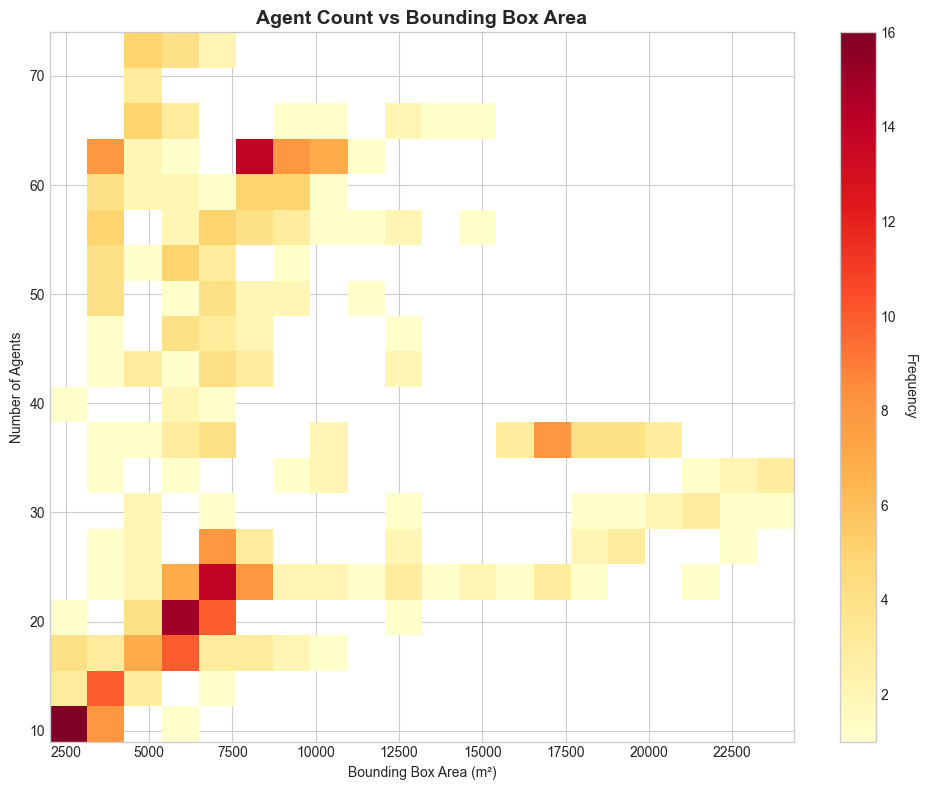

✓ Heatmap saved to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/plots/characterization/density_heatmap_combined.png


In [11]:
# Optional: 2D kernel density heatmap (combined across all scenes)
if len(density_df) > 10:  # Only create if enough data points
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Create 2D histogram/heatmap of num_agents vs bbox_area
    h = ax.hist2d(density_df['bbox_area'], density_df['num_agents'], 
                  bins=20, cmap='YlOrRd', cmin=1)
    
    ax.set_title('Agent Count vs Bounding Box Area', fontsize=14, fontweight='bold')
    ax.set_xlabel('Bounding Box Area (m²)')
    ax.set_ylabel('Number of Agents')
    
    cbar = plt.colorbar(h[3], ax=ax)
    cbar.set_label('Frequency', rotation=270, labelpad=15)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'density_heatmap_combined.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Heatmap saved to {PLOTS_DIR / 'density_heatmap_combined.png'}")
else:
    print("⚠ Insufficient data for heatmap generation")

## Export Metrics

Save computed metrics to CSV files for downstream analysis.

In [12]:
# Save metrics to CSV
agent_counts_df.to_csv(METRICS_DIR / 'instantaneous_agent_counts.csv', index=False)
print(f"✓ Saved instantaneous agent counts to {METRICS_DIR / 'instantaneous_agent_counts.csv'}")

max_agents_per_scene.to_csv(METRICS_DIR / 'max_agents_per_scene.csv', index=False)
print(f"✓ Saved maximum agents per scene to {METRICS_DIR / 'max_agents_per_scene.csv'}")

density_df.to_csv(METRICS_DIR / 'spatial_density.csv', index=False)
print(f"✓ Saved spatial density metrics to {METRICS_DIR / 'spatial_density.csv'}")

✓ Saved instantaneous agent counts to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/metrics/instantaneous_agent_counts.csv
✓ Saved maximum agents per scene to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/metrics/max_agents_per_scene.csv
✓ Saved spatial density metrics to /Users/simondrauz/Lokale Dokumente/Repositories/ds_practical/results/metrics/spatial_density.csv


## Summary Statistics

In [13]:
print("\n" + "="*70)
print("📊 AGENT DENSITY METRICS SUMMARY")
print("="*70)

print(f"\n1. INSTANTANEOUS AGENT COUNTS:")
print(f"   Overall Statistics:")
print(f"   • Total timesteps analyzed: {len(agent_counts_df)}")
print(f"   • Unique scenes: {agent_counts_df['scene_name'].nunique()}")
print(f"   • Mean agents per timestep: {agent_counts_df['num_agents'].mean():.2f}")
print(f"   • Median agents per timestep: {agent_counts_df['num_agents'].median():.2f}")
print(f"   • Std dev: {agent_counts_df['num_agents'].std():.2f}")
print(f"   • Min/Max agents: {agent_counts_df['num_agents'].min():.0f} / {agent_counts_df['num_agents'].max():.0f}")

agent_type_cols = [col for col in agent_counts_df.columns if col.startswith('num_') and col != 'num_agents']
if agent_type_cols:
    print(f"\n   Agent Type Breakdown:")
    for col in sorted(agent_type_cols):
        agent_type = col.replace('num_', '')
        data = agent_counts_df[col]
        total_count = data.sum()
        percentage = (total_count / agent_counts_df['num_agents'].sum()) * 100
        print(f"   • {agent_type}:")
        print(f"      - Mean per timestep: {data.mean():.2f}")
        print(f"      - Max simultaneous: {data.max():.0f}")
        print(f"      - Total agent-timesteps: {total_count:.0f} ({percentage:.1f}%)")

print(f"\n2. MAXIMUM SIMULTANEOUS AGENTS:")
print(f"   Overall Statistics:")
print(f"   • Total scenes analyzed: {len(max_agents_per_scene)}")
print(f"   • Mean max agents per scene: {max_agents_per_scene['max_agents'].mean():.2f}")
print(f"   • Median max agents: {max_agents_per_scene['max_agents'].median():.2f}")
print(f"   • Std dev: {max_agents_per_scene['max_agents'].std():.2f}")
print(f"   • Overall peak: {max_agents_per_scene['max_agents'].max():.0f} agents")

max_type_cols = [col for col in max_agents_per_scene.columns if col.startswith('num_') and col != 'max_agents']
if max_type_cols:
    print(f"\n   Agent Type Breakdown (Peak Counts):")
    for col in sorted(max_type_cols):
        agent_type = col.replace('num_', '')
        data = max_agents_per_scene[col]
        print(f"   • {agent_type}:")
        print(f"      - Peak across all scenes: {data.max():.0f}")
        print(f"      - Mean max per scene: {data.mean():.2f}")
        print(f"      - Median max per scene: {data.median():.2f}")

print(f"\n3. SPATIAL DENSITY:")
print(f"   Overall Statistics:")
print(f"   • Timesteps with density data: {len(density_df)}")
print(f"   • Mean density: {density_df['spatial_density'].mean():.4f} agents/m²")
print(f"   • Median density: {density_df['spatial_density'].median():.4f} agents/m²")
print(f"   • Std dev: {density_df['spatial_density'].std():.4f} agents/m²")
print(f"   • Max density: {density_df['spatial_density'].max():.4f} agents/m²")
print(f"   • Mean bbox area: {density_df['bbox_area'].mean():.2f} m²")
print(f"   • Median bbox area: {density_df['bbox_area'].median():.2f} m²")

density_cols = [col for col in density_df.columns if col.startswith('density_') and col != 'spatial_density']
if density_cols:
    print(f"\n   Agent Type Breakdown (Spatial Density):")
    for col in sorted(density_cols):
        agent_type = col.replace('density_', '')
        data = density_df[col]
        print(f"   • {agent_type}:")
        print(f"      - Mean density: {data.mean():.4f} agents/m²")
        print(f"      - Median density: {data.median():.4f} agents/m²")
        print(f"      - Max density: {data.max():.4f} agents/m²")

print("\n" + "="*70)
if agent_type_cols or max_type_cols or density_cols:
    print("✓ Analysis complete WITH agent type differentiation")
    print("✓ Agent types successfully tracked across all metrics")
else:
    print("✓ Analysis complete (overall metrics only)")
print("✓ Metrics saved to results/metrics/")
print("✓ Plots saved to results/plots/characterization/")
print("="*70)


📊 AGENT DENSITY METRICS SUMMARY

1. INSTANTANEOUS AGENT COUNTS:
   Overall Statistics:
   • Total timesteps analyzed: 404
   • Unique scenes: 10
   • Mean agents per timestep: 37.32
   • Median agents per timestep: 35.00
   • Std dev: 18.75
   • Min/Max agents: 9 / 74

   Agent Type Breakdown:
   • BICYCLE:
      - Mean per timestep: 0.60
      - Max simultaneous: 4
      - Total agent-timesteps: 242 (1.6%)
   • MOTORCYCLE:
      - Mean per timestep: 1.16
      - Max simultaneous: 8
      - Total agent-timesteps: 470 (3.1%)
   • PEDESTRIAN:
      - Mean per timestep: 12.47
      - Max simultaneous: 44
      - Total agent-timesteps: 5038 (33.4%)
   • VEHICLE:
      - Mean per timestep: 23.08
      - Max simultaneous: 61
      - Total agent-timesteps: 9326 (61.9%)

2. MAXIMUM SIMULTANEOUS AGENTS:
   Overall Statistics:
   • Total scenes analyzed: 10
   • Mean max agents per scene: 46.90
   • Median max agents: 50.50
   • Std dev: 21.90
   • Overall peak: 74 agents

   Agent Type Breakdo